In [1]:
import sys, subprocess, pkgutil

def ensure_package(pkg_name, pip_name=None):
    if pkgutil.find_loader(pkg_name) is None:
        name = pip_name or pkg_name
        print(f"Installing {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name])
    else:
        print(f"{pkg_name} already installed.")

for pkg, pip in [("torch", "torch"), ("sklearn", "scikit-learn")]:
    ensure_package(pkg, pip)


torch already installed.
sklearn already installed.


In [15]:
from pathlib import Path

use_day_embedding = True
day_emb_dim       = 3

CONFIG = {
    "BASE_DIR"          : Path("."),
    "PATH_NETWORK"      : Path("Gas Network Data.xlsx"),
    "PATH_CONS_DISTRIB" : Path("./input/Gas Cons Distrib.xlsx"),
    "PATH_CONS_EXPORT"  : Path("./input/Gas Cons Export.xlsx"),
    "PATH_CONS_IND"     : Path("./input/Gas Cons Ind.xlsx"),
    "PATH_DECISION"     : Path("./output/Decision_variablesRU.xlsx"),

    "MONTHS"   : [f"{m:02d}" for m in range(1, 13)],
    "NUM_NODES": 28,
    "WELL_IDX" : [0, 4, 16, 17],
    "TARGET_COLS_ARE_ALL_G": True,

    "HIST_HOURS"    : 72,
    "HORIZON_HOURS" : 24,
    "STRIDE_HOURS"  : 24,

    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END"  : "2024-11-01 00:00:00",

    "USE_PR_HISTORY"                 : False,
    "USE_RES_DEMAND_HISTORY"         : True,
    "USE_IND_DEMAND_HISTORY"         : True,
    "USE_EXP_DEMAND_HISTORY"         : True,
    "USE_GFPP_GAS_LOAD_HISTORY"      : True,
    "USE_G_HISTORY"                  : False,
    "USE_RAW_P_HISTORY_ON_GAS_NODES" : False,

    "USE_NODE_STATIC_IS_WELL"           : True,
    "USE_NODE_STATIC_SHARES"            : False,
    "USE_NODE_STATIC_PRESSURE_BOUNDS"   : False,
    "USE_NODE_STATIC_DEGREE"            : False,
    "USE_NODE_STATIC_IS_GFPP_LOAD_NODE" : False,
    "USE_NODE_STATIC_GFPP_COUNT"        : False,

    "GFPP_P_TO_MW_MULTIPLIER"             : 100.0,
    "GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3": 11000.0,
    "GFPP_DEFAULT_EFFICIENCY"             : 0.55,
    "GFPP_EFFICIENCY_BY_GENERATOR"        : {},
    "GFPP_USE_OPTIONAL_EFFICIENCY_COLUMN" : False,
    "GFPP_OPTIONAL_EFFICIENCY_COLUMN_NAME": "Efficiency",

    "MLP_HIDDEN_DIMS" : [512, 256, 128],
    "DROPOUT"         : 0.1,
    "USE_BATCHNORM"   : True,

    "SEED"                    : 42,
    "DEVICE"                  : "cpu",
    "EPOCHS"                  : 100,
    "BATCH_SIZE"              : 24,
    "LR"                      : 5e-4,
    "WEIGHT_DECAY"            : 1e-4,
    "GRAD_CLIP_NORM"          : 2.0,
    "EARLY_STOPPING_PATIENCE" : 30,
    "EARLY_STOPPING_MIN_DELTA": 0.0,
    "SCHEDULER_FACTOR"        : 0.6,
    "SCHEDULER_PATIENCE"      : 4,
    "SCHEDULER_MIN_LR"        : 1e-5,

    "NUM_ALIGNMENT_CHECKS" : 10,
    "NUM_PLOT_SAMPLES"     : 3,
    "PLOT_WELL_LOCAL_INDEX": 0,
    "SAVE_MODEL_STATE"     : False,
    "MODEL_STATE_PATH"     : Path("mlp_gas.pt"),
}

PATHS = {
    "network"      : CONFIG["BASE_DIR"] / CONFIG["PATH_NETWORK"],
    "cons_distrib" : CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_DISTRIB"],
    "cons_export"  : CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_EXPORT"],
    "cons_ind"     : CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_IND"],
    "decision"     : CONFIG["BASE_DIR"] / CONFIG["PATH_DECISION"],
}

HIST    = CONFIG["HIST_HOURS"]
HOR     = CONFIG["HORIZON_HOURS"]
STR     = CONFIG["STRIDE_HOURS"]
N_WELLS = len(CONFIG["WELL_IDX"])

print("Expected files:")
for k, v in PATHS.items():
    print(f"  {k}: {v.resolve()} | exists={v.exists()}")
for p in PATHS.values():
    assert p.exists(), f"File not found: {p}"
print(f"\nCONFIG OK.  use_day_embedding={use_day_embedding}  day_emb_dim={day_emb_dim}")


Expected files:
  network: C:\Users\yoans\TFE - GAZ\Gas Network Data.xlsx | exists=True
  cons_distrib: C:\Users\yoans\TFE - GAZ\input\Gas Cons Distrib.xlsx | exists=True
  cons_export: C:\Users\yoans\TFE - GAZ\input\Gas Cons Export.xlsx | exists=True
  cons_ind: C:\Users\yoans\TFE - GAZ\input\Gas Cons Ind.xlsx | exists=True
  decision: C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx | exists=True

CONFIG OK.  use_day_embedding=True  day_emb_dim=3


In [16]:
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

DEVICE = torch.device(
    "cuda" if (CONFIG["DEVICE"] == "cuda" and torch.cuda.is_available()) else "cpu"
)
print("DEVICE =", DEVICE)

def pretty_shape(name, x):
    if isinstance(x, (np.ndarray, torch.Tensor, pd.DataFrame, pd.Series)):
        print(f"{name}: shape={getattr(x, 'shape', None)}")
    else:
        print(f"{name}: type={type(x)}")

def drop_unnamed_first_col(df):
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        return df.drop(columns=[df.columns[0]])
    return df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


DEVICE = cpu


In [17]:
def show_excel_overview(path, n_preview_rows=3):
    xls = pd.ExcelFile(path)
    print("=" * 100)
    print(path.name)
    for sheet in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet, nrows=n_preview_rows)
        print(f"  [{sheet}]  {df.shape}")
    print()

# show_excel_overview(PATHS["network"])


In [18]:
nodes_df       = pd.read_excel(PATHS["network"], sheet_name="Nodes")
pipes_df       = pd.read_excel(PATHS["network"], sheet_name="Pipelines")
well_df        = pd.read_excel(PATHS["network"], sheet_name="Well")
gaswell_map_df = pd.read_excel(PATHS["network"], sheet_name="GasWellMap")
gfpp_map_df    = pd.read_excel(PATHS["network"], sheet_name="GFPPMap")
ki_df          = pd.read_excel(PATHS["network"], sheet_name="KI")
ko_df          = pd.read_excel(PATHS["network"], sheet_name="KO")

num_nodes = CONFIG["NUM_NODES"]
well_idx  = CONFIG["WELL_IDX"]

for name, df in [("nodes_df", nodes_df), ("pipes_df", pipes_df), ("well_df", well_df),
                 ("gaswell_map_df", gaswell_map_df), ("gfpp_map_df", gfpp_map_df),
                 ("ki_df", ki_df), ("ko_df", ko_df)]:
    pretty_shape(name, df)

assert len(nodes_df) == num_nodes
assert len(well_idx) == 4
assert pipes_df["From node"].min() >= 1 and pipes_df["To node"].min() >= 1
assert pipes_df["From node"].max() <= num_nodes and pipes_df["To node"].max() <= num_nodes

print("Nodes columns    :", list(nodes_df.columns))
print("Pipelines columns:", list(pipes_df.columns))
print("GFPPMap columns  :", list(gfpp_map_df.columns))

display(nodes_df.head())
display(pipes_df.head())
display(well_df)


nodes_df: shape=(28, 6)
pipes_df: shape=(33, 10)
well_df: shape=(4, 10)
gaswell_map_df: shape=(28, 4)
gfpp_map_df: shape=(28, 24)
ki_df: shape=(9, 12)
ko_df: shape=(26, 12)
Nodes columns    : ['Gas Node', 'Res_Load_share_%', 'Ind_Load_share_%', 'Exp_Load_share_%', 'Pr_min [bar]', 'Pr_max [bar]']
Pipelines columns: ['Pipeline', 'From node', 'To node', 'Natural gas flow constant [MNm3/(bar*h)2]', 'Compressor factor', 'High Linepack', 'Initial linepack [MNm3]', 'Linepack constant [MNm3/bar]', 'Estimated lenght [km]', 'Linepack constant quantifies']
GFPPMap columns  : ['Gen1', 'Gen2', 'Gen3', 'Gen4', 'Gen5', 'Gen6', 'Gen7', 'Gen8', 'Gen9', 'Gen10', 'Gen11', 'Gen12', 'Gen13', 'Gen14', 'Gen15', 'Gen16', 'Gen17', 'Gen18', 'Gen19', 'Gen20', 'Gen21', 'Gen22', 'Gen23', 'Gen24']


,Gas Node,Res_Load_share_%,Ind_Load_share_%,Exp_Load_share_%,Pr_min [bar],Pr_max [bar]
0,1,0.000000,0.000000,0.0,60,80
1,2,0.055556,0.105263,0.0,60,80
2,3,0.055556,0.052632,0.0,60,80
3,4,0.055556,0.052632,0.0,60,80
4,5,0.000000,0.000000,0.0,60,80


,Pipeline,From node,To node,Natural gas flow constant [MNm3/(bar*h)2],Compressor factor,High Linepack,Initial linepack [MNm3],Linepack constant [MNm3/bar],Estimated lenght [km],Linepack constant quantifies
0,1,1,2,0.14400,1.0,1,12.144166,0.1680,25.0,how much gas volume is
1,2,2,3,0.00739,1.0,1,10.592369,0.1470,30.0,added or removed from the
2,3,2,4,0.08270,1.0,1,2.515726,0.0349,35.0,pipeline for each change in pressure
3,4,2,6,0.08270,1.0,1,2.516711,0.0349,30.0,NaN
4,5,3,27,0.07670,1.0,0,0.000000,0.0142,65.0,NaN


,Gas node,Gmax [MNm3/h],Day-ahead offer price [€/MNm3],Spot Market TTF Q4 2024 :,Unnamed: 4,Unnamed: 5,GCV moyen décembre :,Unnamed: 7,Unnamed: 8,OLD Day-ahead offer price (€/Mm3)
0,1,4.0,497394,43.251667,€/MWh,NaN,11.5,kWh/Nm3,NaN,65717.14
1,5,2.5,497394,0.043252,€/kWh,NaN,NaN,NaN,NaN,78860.57
2,17,2.2,497394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,1.5,497394,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
def read_simple_monthly_series(path, months, value_col):
    parts = []
    for m in months:
        df = pd.read_excel(path, sheet_name=f"{m}-2024")
        df = df[["Date Time", value_col]].copy()
        df["Date Time"] = pd.to_datetime(df["Date Time"])
        df = df.rename(columns={value_col: "value"})
        df["month"] = m
        parts.append(df)
    return pd.concat(parts, ignore_index=True).sort_values("Date Time").reset_index(drop=True)

def read_decision_tensor(prefix, months, decision_path):
    all_values, all_times = [], []
    for m in months:
        df = pd.read_excel(decision_path, sheet_name=f"{prefix}-{m}-2024")
        df = drop_unnamed_first_col(df)
        arr = df.to_numpy(dtype=float)
        idx = pd.date_range(start=pd.Timestamp(f"2024-{m}-01"), periods=len(df), freq="h")
        all_values.append(arr)
        all_times.append(idx)
    values = np.vstack(all_values)
    times  = pd.DatetimeIndex(np.concatenate([x.to_numpy() for x in all_times]))
    return values, times


In [20]:
MONTHS = CONFIG["MONTHS"]

cons_distrib_df = read_simple_monthly_series(PATHS["cons_distrib"], MONTHS, "Physical Flow (MNm3)")
cons_ind_df     = read_simple_monthly_series(PATHS["cons_ind"],     MONTHS, "Physical Flow (MNm3)")
cons_export_df  = read_simple_monthly_series(PATHS["cons_export"],  MONTHS, "Physical Flow (MNm3)")

g_full,  ts_g  = read_decision_tensor("g",  MONTHS, PATHS["decision"])
pr_full, ts_pr = read_decision_tensor("pr", MONTHS, PATHS["decision"])
q_full,  ts_q  = read_decision_tensor("q",  MONTHS, PATHS["decision"])
p_full,  ts_p  = read_decision_tensor("p",  MONTHS, PATHS["decision"])

assert len(cons_distrib_df) == len(cons_ind_df) == len(cons_export_df)
assert len(ts_g) == len(ts_pr) == len(ts_q) == len(ts_p) == len(cons_distrib_df)
assert (ts_g == ts_pr).all() and (ts_g == ts_q).all() and (ts_g == ts_p).all()
assert g_full.shape[1] == 4
assert pr_full.shape[1] == CONFIG["NUM_NODES"]
assert p_full.shape[1]  == gfpp_map_df.shape[1]

print("Time range:", ts_g.min(), "->", ts_g.max())
print("Total hours:", len(ts_g))
for name, arr in [("g_full", g_full), ("pr_full", pr_full), ("p_full", p_full)]:
    pretty_shape(name, arr)


Time range: 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
Total hours: 8784
g_full: shape=(8784, 4)
pr_full: shape=(8784, 28)
p_full: shape=(8784, 24)


In [21]:
gfpp_map    = gfpp_map_df.to_numpy(dtype=float)
gen_cols    = list(gfpp_map_df.columns)
num_generators = len(gen_cols)

assert gfpp_map.shape == (num_nodes, num_generators)

generator_to_gas_node = {}
generators_without_gas_node = []
generators_with_multiple_nodes = []

for g_idx, gen_name in enumerate(gen_cols):
    connected_rows = np.where(gfpp_map[:, g_idx] > 0.5)[0]
    if len(connected_rows) == 0:
        generators_without_gas_node.append(g_idx)
    elif len(connected_rows) == 1:
        generator_to_gas_node[g_idx] = int(connected_rows[0])
    else:
        generators_with_multiple_nodes.append((g_idx, connected_rows.tolist()))

assert len(generators_with_multiple_nodes) == 0

connected_generator_idx = sorted(generator_to_gas_node.keys())
connected_gas_nodes     = sorted(set(generator_to_gas_node.values()))

print("Generators connected to gas:", len(connected_generator_idx))
print("GFPP gas nodes (0-based)   :", connected_gas_nodes)
print("GFPP gas nodes (1-based)   :", [n + 1 for n in connected_gas_nodes])

gfpp_count_per_node = np.zeros(num_nodes, dtype=int)
for g_idx, node_idx in generator_to_gas_node.items():
    gfpp_count_per_node[node_idx] += 1

gfpp_is_load_node = (gfpp_count_per_node > 0).astype(float)


Generators connected to gas: 22
GFPP gas nodes (0-based)   : [1, 2, 5, 7, 8, 10, 12, 18, 22, 23, 26]
GFPP gas nodes (1-based)   : [2, 3, 6, 8, 9, 11, 13, 19, 23, 24, 27]


In [22]:
eff_by_gen = np.full(num_generators, CONFIG["GFPP_DEFAULT_EFFICIENCY"], dtype=float)
for g_idx, eff_val in CONFIG["GFPP_EFFICIENCY_BY_GENERATOR"].items():
    eff_by_gen[g_idx] = float(eff_val)

base_multiplier    = float(CONFIG["GFPP_P_TO_MW_MULTIPLIER"])
gas_energy_content = float(CONFIG["GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3"])

p_full_mw = p_full * base_multiplier

gfpp_gas_consumption_per_gen = np.zeros_like(p_full_mw, dtype=float)
for g_idx in connected_generator_idx:
    gfpp_gas_consumption_per_gen[:, g_idx] = (
        p_full_mw[:, g_idx] / (gas_energy_content * eff_by_gen[g_idx])
    )

gfpp_gas_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
for g_idx in connected_generator_idx:
    node_idx = generator_to_gas_node[g_idx]
    gfpp_gas_nodal[:, node_idx] += gfpp_gas_consumption_per_gen[:, g_idx]

pretty_shape("gfpp_gas_nodal", gfpp_gas_nodal)
print("GFPP aggregation OK.")
print(f"  min={gfpp_gas_nodal.min():.6f}  max={gfpp_gas_nodal.max():.6f}  mean={gfpp_gas_nodal.mean():.6f}")


gfpp_gas_nodal: shape=(8784, 28)
GFPP aggregation OK.
  min=0.000000  max=0.205289  mean=0.013867


In [23]:
print("=== GFPP DIAGNOSTIC ===")
print("Generators connected to gas:", len(connected_generator_idx))
print("p indices (0-based)        :", connected_generator_idx)
print("Impacted gas nodes (0-based):", connected_gas_nodes)
print("gfpp_gas_nodal shape        :", gfpp_gas_nodal.shape)

rows = []
for hour_idx in [0, 1, 2, 24, 48, 72]:
    for node_idx in connected_gas_nodes[:min(8, len(connected_gas_nodes))]:
        gens_here = [g for g, n in generator_to_gas_node.items() if n == node_idx]
        row = {
            "hour_idx"             : hour_idx,
            "timestamp"            : ts_g[hour_idx],
            "gas_node_0based"      : node_idx,
            "gas_node_1based"      : node_idx + 1,
            "n_generators_on_node" : len(gens_here),
            "aggregated_node_value": gfpp_gas_nodal[hour_idx, node_idx],
            "sum_generators"       : gfpp_gas_consumption_per_gen[hour_idx, gens_here].sum(),
        }
        rows.append(row)

gfpp_diag_df = pd.DataFrame(rows)
gfpp_diag_df["abs_diff"] = np.abs(gfpp_diag_df["aggregated_node_value"] - gfpp_diag_df["sum_generators"])
assert np.all(gfpp_diag_df["abs_diff"] < 1e-12)
display(gfpp_diag_df.head(20))


=== GFPP DIAGNOSTIC ===
Generators connected to gas: 22
p indices (0-based)        : [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23]
Impacted gas nodes (0-based): [1, 2, 5, 7, 8, 10, 12, 18, 22, 23, 26]
gfpp_gas_nodal shape        : (8784, 28)


,hour_idx,timestamp,gas_node_0based,gas_node_1based,n_generators_on_node,aggregated_node_value,sum_generators,abs_diff
0,0,2024-01-01 00:00:00,1,2,2,0.000000,0.000000,0.0
1,0,2024-01-01 00:00:00,2,3,1,0.000000,0.000000,0.0
2,0,2024-01-01 00:00:00,5,6,4,0.000000,0.000000,0.0
3,0,2024-01-01 00:00:00,7,8,5,0.000000,0.000000,0.0
4,0,2024-01-01 00:00:00,8,9,1,0.000000,0.000000,0.0
5,0,2024-01-01 00:00:00,10,11,1,0.060422,0.060422,0.0
6,0,2024-01-01 00:00:00,12,13,1,0.000000,0.000000,0.0
7,0,2024-01-01 00:00:00,18,19,3,0.000000,0.000000,0.0
8,1,2024-01-01 01:00:00,1,2,2,0.000000,0.000000,0.0
9,1,2024-01-01 01:00:00,2,3,1,0.000000,0.000000,0.0


In [24]:
res_share = nodes_df["Res_Load_share_%"].to_numpy(dtype=float)
ind_share = nodes_df["Ind_Load_share_%"].to_numpy(dtype=float)
exp_share = nodes_df["Exp_Load_share_%"].to_numpy(dtype=float)

res_total = cons_distrib_df["value"].to_numpy(dtype=float)
ind_total = cons_ind_df["value"].to_numpy(dtype=float)
exp_total = cons_export_df["value"].to_numpy(dtype=float)

res_nodal = res_total[:, None] * res_share[None, :]
ind_nodal = ind_total[:, None] * ind_share[None, :]
exp_nodal = exp_total[:, None] * exp_share[None, :]

g_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
g_nodal[:, well_idx] = g_full

p_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
for g_idx in connected_generator_idx:
    p_nodal[:, generator_to_gas_node[g_idx]] += p_full[:, g_idx]

dyn_feature_dict = {}
if CONFIG["USE_PR_HISTORY"]:
    dyn_feature_dict["pr"] = pr_full
if CONFIG["USE_RES_DEMAND_HISTORY"]:
    dyn_feature_dict["res_demand"] = res_nodal
if CONFIG["USE_IND_DEMAND_HISTORY"]:
    dyn_feature_dict["ind_demand"] = ind_nodal
if CONFIG["USE_EXP_DEMAND_HISTORY"]:
    dyn_feature_dict["exp_demand"] = exp_nodal
if CONFIG["USE_GFPP_GAS_LOAD_HISTORY"]:
    dyn_feature_dict["gfpp_gas_load"] = gfpp_gas_nodal
if CONFIG["USE_G_HISTORY"]:
    dyn_feature_dict["g_history"] = g_nodal
if CONFIG["USE_RAW_P_HISTORY_ON_GAS_NODES"]:
    dyn_feature_dict["p_history_projected_to_gas_nodes"] = p_nodal

assert len(dyn_feature_dict) > 0
dyn_feature_names = list(dyn_feature_dict.keys())
dyn_tensor = np.stack([dyn_feature_dict[k] for k in dyn_feature_names], axis=-1)

print("Dynamic features:", dyn_feature_names)
pretty_shape("dyn_tensor [T, N, F_dyn]", dyn_tensor)
assert dyn_tensor.shape == (len(ts_g), num_nodes, len(dyn_feature_names))


Dynamic features: ['res_demand', 'ind_demand', 'exp_demand', 'gfpp_gas_load']
dyn_tensor [T, N, F_dyn]: shape=(8784, 28, 4)


In [25]:
degrees = np.zeros(num_nodes, dtype=float)
for _, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"])   - 1
    degrees[u] += 1
    degrees[v] += 1

node_static_parts = []
node_static_names = []

if CONFIG["USE_NODE_STATIC_IS_WELL"]:
    is_well = np.zeros(num_nodes, dtype=float)
    is_well[well_idx] = 1.0
    node_static_parts.append(is_well[:, None])
    node_static_names.append("is_well")

if CONFIG["USE_NODE_STATIC_SHARES"]:
    node_static_parts.extend([res_share[:, None], ind_share[:, None], exp_share[:, None]])
    node_static_names.extend(["res_share", "ind_share", "exp_share"])

if CONFIG["USE_NODE_STATIC_PRESSURE_BOUNDS"]:
    pr_min = nodes_df["Pr_min [bar]"].to_numpy(dtype=float)
    pr_max = nodes_df["Pr_max [bar]"].to_numpy(dtype=float)
    node_static_parts.extend([pr_min[:, None], pr_max[:, None]])
    node_static_names.extend(["pr_min", "pr_max"])

if CONFIG["USE_NODE_STATIC_DEGREE"]:
    node_static_parts.append(degrees[:, None])
    node_static_names.append("degree")

if CONFIG["USE_NODE_STATIC_IS_GFPP_LOAD_NODE"]:
    node_static_parts.append(gfpp_is_load_node[:, None])
    node_static_names.append("is_gfpp_load_node")

if CONFIG["USE_NODE_STATIC_GFPP_COUNT"]:
    node_static_parts.append(gfpp_count_per_node[:, None].astype(float))
    node_static_names.append("gfpp_generator_count")

node_static = (
    np.concatenate(node_static_parts, axis=1)
    if node_static_parts
    else np.zeros((num_nodes, 0), dtype=float)
)

pretty_shape("node_static [N, F_static]", node_static)
print("node_static_names =", node_static_names)


node_static [N, F_static]: shape=(28, 1)
node_static_names = ['is_well']


In [26]:
ts_g = pd.to_datetime(ts_g)

day_of_week = ts_g.dayofweek.to_numpy(dtype=np.int64)
is_weekend  = (day_of_week >= 5).astype(np.int64)

print("Time range         :", ts_g.min(), "->", ts_g.max())
print("day_of_week [0=Mon … 6=Sun] min/max:", day_of_week.min(), "/", day_of_week.max())
print("Weekend hours               :", int(is_weekend.sum()))

display(pd.DataFrame({
    "datetime"   : ts_g[:8],
    "day_of_week": day_of_week[:8],
    "is_weekend" : is_weekend[:8],
}))


Time range         : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
day_of_week [0=Mon … 6=Sun] min/max: 0 / 6
Weekend hours               : 2496


,datetime,day_of_week,is_weekend
0,2024-01-01 00:00:00,0,0
1,2024-01-01 01:00:00,0,0
2,2024-01-01 02:00:00,0,0
3,2024-01-01 03:00:00,0,0
4,2024-01-01 04:00:00,0,0
5,2024-01-01 05:00:00,0,0
6,2024-01-01 06:00:00,0,0
7,2024-01-01 07:00:00,0,0


In [27]:
TRAIN_END = pd.Timestamp(CONFIG["TRAIN_END"])
VAL_END   = pd.Timestamp(CONFIG["VAL_END"])

all_start_indices = np.arange(0, len(ts_g) - HIST - HOR + 1, STR, dtype=int)
target_start_times = ts_g[all_start_indices + HIST]

train_window_mask = target_start_times < TRAIN_END
val_window_mask   = (target_start_times >= TRAIN_END) & (target_start_times < VAL_END)
test_window_mask  = target_start_times >= VAL_END

print("Total windows:", len(all_start_indices))
print("  Train       :", int(train_window_mask.sum()))
print("  Val         :", int(val_window_mask.sum()))
print("  Test        :", int(test_window_mask.sum()))

hour_train_mask = ts_g < TRAIN_END
F_dyn = dyn_tensor.shape[-1]

dyn_scaler = StandardScaler()
dyn_scaler.fit(dyn_tensor[hour_train_mask].reshape(-1, F_dyn))
dyn_tensor_scaled = dyn_scaler.transform(dyn_tensor.reshape(-1, F_dyn)).reshape(dyn_tensor.shape)

if node_static.shape[1] > 0:
    node_static_scaler = StandardScaler()
    node_static_scaler.fit(node_static)
    node_static_scaled = node_static_scaler.transform(node_static)
else:
    node_static_scaler = None
    node_static_scaled = node_static.copy()

target_scaler = StandardScaler()
target_scaler.fit(g_full[hour_train_mask].reshape(-1, 1))
g_full_scaled = target_scaler.transform(g_full.reshape(-1, 1)).reshape(g_full.shape)

expected_x_dim = HIST * F_dyn + node_static_scaled.shape[1]
flat_input_dim = num_nodes * expected_x_dim

print(f"\nexpected_x_dim (per node)  = {expected_x_dim}")
print(f"flat_input_dim (MLP input) = {flat_input_dim}")
print("target_scaler mean/scale:", target_scaler.mean_, target_scaler.scale_)
pretty_shape("dyn_tensor_scaled",  dyn_tensor_scaled)
pretty_shape("node_static_scaled", node_static_scaled)
pretty_shape("g_full_scaled",      g_full_scaled)


Total windows: 363
  Train       : 271
  Val         : 31
  Test        : 61

expected_x_dim (per node)  = 289
flat_input_dim (MLP input) = 8092
target_scaler mean/scale: [1.21370289] [0.84398355]
dyn_tensor_scaled: shape=(8784, 28, 4)
node_static_scaled: shape=(28, 1)
g_full_scaled: shape=(8784, 4)


In [28]:
def build_single_window(start_idx):
    hist_dyn = dyn_tensor_scaled[start_idx : start_idx + HIST]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2)).reshape(num_nodes, -1)
    x        = np.concatenate([hist_dyn, node_static_scaled], axis=1)  # (num_nodes, expected_x_dim)
    x_flat   = x.reshape(-1)                                            # (flat_input_dim,)

    y      = g_full_scaled[start_idx + HIST : start_idx + HIST + HOR].T
    y_real = g_full[start_idx + HIST        : start_idx + HIST + HOR].T

    dow_idx = int(day_of_week[start_idx + HIST])

    return {
        "x"                : x.astype(np.float32),
        "x_flat"           : x_flat.astype(np.float32),
        "y"                : y.astype(np.float32),
        "y_real"           : y_real.astype(np.float32),
        "dow"              : dow_idx,
        "start_idx"        : np.int64(start_idx),
        "hist_start_idx"   : np.int64(start_idx),
        "hist_end_idx"     : np.int64(start_idx + HIST - 1),
        "target_start_idx" : np.int64(start_idx + HIST),
        "target_end_idx"   : np.int64(start_idx + HIST + HOR - 1),
    }

sample0 = build_single_window(int(all_start_indices[0]))
assert sample0["x"].shape      == (num_nodes, expected_x_dim)
assert sample0["x_flat"].shape == (flat_input_dim,)
assert sample0["y"].shape      == (N_WELLS, HOR)
print("build_single_window OK.")

def check_alignment_for_window(start_idx, verbose=True):
    s = build_single_window(start_idx)
    ts0, ts1 = int(s["target_start_idx"]), int(s["target_end_idx"])
    expected = g_full[ts0 : ts1 + 1].T
    assert np.allclose(expected, s["y_real"]), "Alignment error in y_real"
    if verbose:
        print(f"Alignment OK | start={start_idx} | {ts_g[ts0]} -> {ts_g[ts1]}")

for idx in [all_start_indices[0], all_start_indices[min(10, len(all_start_indices)-1)], all_start_indices[-1]]:
    check_alignment_for_window(int(idx))
print("Alignment checks passed.")


build_single_window OK.
Alignment OK | start=0 | 2024-01-04 00:00:00 -> 2024-01-04 23:00:00
Alignment OK | start=240 | 2024-01-14 00:00:00 -> 2024-01-14 23:00:00
Alignment OK | start=8688 | 2024-12-31 00:00:00 -> 2024-12-31 23:00:00
Alignment checks passed.


In [29]:
class GasMLPDataset(Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx):
        s = build_single_window(int(self.start_indices[idx]))
        return (
            torch.tensor(s["x_flat"], dtype=torch.float32),
            torch.tensor(s["y"],      dtype=torch.float32),
            torch.tensor(s["dow"],    dtype=torch.long),
            torch.tensor(s["target_start_idx"], dtype=torch.long),
            torch.tensor(s["y_real"], dtype=torch.float32),
        )

train_ds = GasMLPDataset(all_start_indices[train_window_mask])
val_ds   = GasMLPDataset(all_start_indices[val_window_mask])
test_ds  = GasMLPDataset(all_start_indices[test_window_mask])

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print(f"len(train_ds) = {len(train_ds)}")
print(f"len(val_ds)   = {len(val_ds)}")
print(f"len(test_ds)  = {len(test_ds)}")

x_batch, y_batch, dow_batch, meta_batch, yreal_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  x_flat : {x_batch.shape}   (batch_size x flat_input_dim)")
print(f"  y      : {y_batch.shape}   (batch_size x N_WELLS x HOR)")
print(f"  dow    : {dow_batch.shape}")
assert x_batch.shape[1]  == flat_input_dim
assert y_batch.shape[1:] == (N_WELLS, HOR)
print("GasMLPDataset OK.")


len(train_ds) = 271
len(val_ds)   = 31
len(test_ds)  = 61

Batch shapes:
  x_flat : torch.Size([24, 8092])   (batch_size x flat_input_dim)
  y      : torch.Size([24, 4, 24])   (batch_size x N_WELLS x HOR)
  dow    : torch.Size([24])
GasMLPDataset OK.


In [30]:
class MLP(nn.Module):
    def __init__(self, dims, dropout=0.0, use_batchnorm=False, activate_last=False):
        super().__init__()
        self.dims         = list(dims)
        self.in_channels  = self.dims[0]
        self.out_channels = self.dims[-1]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            is_last = (i == len(dims) - 2)
            if (not is_last) or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(dims[i+1]))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [31]:
class GasMLP(nn.Module):
    def __init__(
        self,
        flat_input_dim,
        n_wells,
        horizon,
        hidden_dims=(512, 256, 128),
        dropout=0.1,
        use_batchnorm=True,
        use_day_embedding=False,
        day_emb_dim=3,
    ):
        super().__init__()
        self.n_wells           = n_wells
        self.horizon           = horizon
        self.use_day_embedding = use_day_embedding

        if use_day_embedding:
            self.day_embedding = nn.Embedding(7, day_emb_dim)
            in_dim = flat_input_dim + day_emb_dim
        else:
            in_dim = flat_input_dim

        dims = [in_dim] + list(hidden_dims) + [n_wells * horizon]
        self.net = MLP(dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x_flat, dow=None):
        if self.use_day_embedding and dow is not None:
            dow_emb = self.day_embedding(dow)
            x_flat  = torch.cat([x_flat, dow_emb], dim=1)
        out = self.net(x_flat)
        return out.view(-1, self.n_wells, self.horizon)


model = GasMLP(
    flat_input_dim    = flat_input_dim,
    n_wells           = N_WELLS,
    horizon           = HOR,
    hidden_dims       = CONFIG["MLP_HIDDEN_DIMS"],
    dropout           = CONFIG["DROPOUT"],
    use_batchnorm     = CONFIG["USE_BATCHNORM"],
    use_day_embedding = use_day_embedding,
    day_emb_dim       = day_emb_dim,
).to(DEVICE)

print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

x_test, y_test, dow_test, _, _ = next(iter(train_loader))
x_test   = x_test.to(DEVICE)
dow_test = dow_test.to(DEVICE)
with torch.no_grad():
    pred_test = model(x_test, dow=dow_test if use_day_embedding else None)
print(f"Forward OK  pred_test.shape = {pred_test.shape}  (expected: {y_test.shape})")
assert pred_test.shape == y_test.shape


GasMLP(
  (day_embedding): Embedding(7, 3)
  (net): MLP(
    (net): Sequential(
      (0): Linear(in_features=8095, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=256, out_features=128, bias=True)
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
      (12): Linear(in_features=128, out_features=96, bias=True)
    )
  )
)

Trainable parameters: 4,323,573
Forward OK  pred_test.shape = torch.Size([24, 4, 24])  (expected: torch.Size([24, 4, 24]))


In [32]:
def mse_loss_gas(pred, y_true):
    return F.mse_loss(pred, y_true.view_as(pred))

def inverse_transform_targets(arr_scaled):
    arr = np.asarray(arr_scaled)
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape)

def mae_rmse_nmae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae    = np.mean(np.abs(y_pred - y_true))
    rmse   = np.sqrt(np.mean((y_pred - y_true) ** 2))
    nmae   = mae / (np.mean(np.abs(y_true)) + 1e-12)
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}

def run_one_epoch(mdl, loader, optimizer=None):
    is_train = optimizer is not None
    mdl.train() if is_train else mdl.eval()
    total_loss, total_samples = 0.0, 0
    for x_flat, y_true, dow, _, _ in loader:
        x_flat = x_flat.to(DEVICE)
        y_true = y_true.to(DEVICE)
        dow    = dow.to(DEVICE)
        bsz    = x_flat.shape[0]
        with torch.set_grad_enabled(is_train):
            pred = mdl(x_flat, dow=dow if use_day_embedding else None)
            loss = mse_loss_gas(pred, y_true)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if CONFIG["GRAD_CLIP_NORM"] is not None:
                    torch.nn.utils.clip_grad_norm_(mdl.parameters(), CONFIG["GRAD_CLIP_NORM"])
                optimizer.step()
        total_loss    += loss.item() * bsz
        total_samples += bsz
    return total_loss / max(total_samples, 1)


In [33]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = np.inf
        self.best_state  = None
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = float(val_loss)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


In [34]:
model = GasMLP(
    flat_input_dim    = flat_input_dim,
    n_wells           = N_WELLS,
    horizon           = HOR,
    hidden_dims       = CONFIG["MLP_HIDDEN_DIMS"],
    dropout           = CONFIG["DROPOUT"],
    use_batchnorm     = CONFIG["USE_BATCHNORM"],
    use_day_embedding = use_day_embedding,
    day_emb_dim       = day_emb_dim,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"], min_lr=CONFIG["SCHEDULER_MIN_LR"],
)
early_stopper = EarlyStopping(
    patience  = CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta = CONFIG["EARLY_STOPPING_MIN_DELTA"],
)
history = {"train_loss": [], "val_loss": [], "lr": []}

print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("\nModel / optimizer / scheduler / history initialized.")


GasMLP(
  (day_embedding): Embedding(7, 3)
  (net): MLP(
    (net): Sequential(
      (0): Linear(in_features=8095, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=256, out_features=128, bias=True)
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
      (12): Linear(in_features=128, out_features=96, bias=True)
    )
  )
)

Trainable parameters: 4,323,573

Model / optimizer / scheduler / history initialized.


In [35]:
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss   = run_one_epoch(model, val_loader,   optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_loss:.6f} | val={val_loss:.6f} | "
        f"counter={early_stopper.counter}/{early_stopper.patience} | lr={current_lr:.2e}"
    )

    if early_stopper.step(val_loss, model):
        print(f"Early stopping triggered at epoch {epoch}.")
        break

assert early_stopper.best_state is not None
model.load_state_dict(early_stopper.best_state)
print("\nBest val_loss:", early_stopper.best_loss)

if CONFIG["SAVE_MODEL_STATE"]:
    torch.save(model.state_dict(), CONFIG["MODEL_STATE_PATH"])
    print("Model saved to", CONFIG["MODEL_STATE_PATH"])


Epoch 001 | train=0.921200 | val=0.731570 | counter=0/30 | lr=5.00e-04
Epoch 002 | train=0.539356 | val=0.412228 | counter=0/30 | lr=5.00e-04
Epoch 003 | train=0.339385 | val=0.266703 | counter=0/30 | lr=5.00e-04
Epoch 004 | train=0.253300 | val=0.212567 | counter=0/30 | lr=5.00e-04
Epoch 005 | train=0.228231 | val=0.192735 | counter=0/30 | lr=5.00e-04
Epoch 006 | train=0.202858 | val=0.183751 | counter=0/30 | lr=5.00e-04
Epoch 007 | train=0.203436 | val=0.172313 | counter=0/30 | lr=5.00e-04
Epoch 008 | train=0.193122 | val=0.171261 | counter=0/30 | lr=5.00e-04
Epoch 009 | train=0.184140 | val=0.177477 | counter=0/30 | lr=5.00e-04
Epoch 010 | train=0.186397 | val=0.169594 | counter=1/30 | lr=5.00e-04
Epoch 011 | train=0.177096 | val=0.162512 | counter=0/30 | lr=5.00e-04
Epoch 012 | train=0.173926 | val=0.167107 | counter=0/30 | lr=5.00e-04
Epoch 013 | train=0.183699 | val=0.165883 | counter=1/30 | lr=5.00e-04
Epoch 014 | train=0.170884 | val=0.164120 | counter=2/30 | lr=5.00e-04
Epoch 

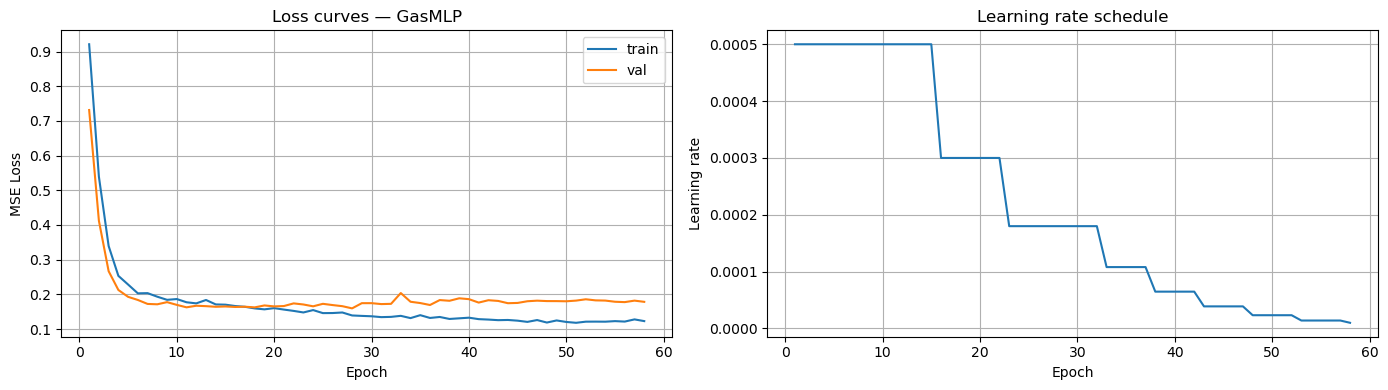

Training finished in 58 epochs.
Best val_loss = 0.159528


In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_ran, history["train_loss"], label="train")
ax1.plot(epochs_ran, history["val_loss"],   label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("Loss curves — GasMLP"); ax1.legend(); ax1.grid(True)

ax2.plot(epochs_ran, history["lr"])
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning rate")
ax2.set_title("Learning rate schedule"); ax2.grid(True)

plt.tight_layout()
plt.show()
print(f"Training finished in {len(history['train_loss'])} epochs.")
print(f"Best val_loss = {early_stopper.best_loss:.6f}")


In [37]:
def ensure_3d_output(arr, n_wells, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_wells and arr.shape[2] == horizon
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon
        assert arr.shape[0] % n_wells == 0
        return arr.reshape(arr.shape[0] // n_wells, n_wells, horizon)
    raise ValueError(f"Unsupported ndim: {arr.ndim}")

@torch.no_grad()
def collect_predictions(mdl, loader):
    mdl.eval()
    preds_scaled, trues_scaled, preds_real, trues_real, metas = [], [], [], [], []
    for x_flat, y_true, dow, meta, y_real_batch in loader:
        x_flat = x_flat.to(DEVICE)
        dow    = dow.to(DEVICE)
        pred   = mdl(x_flat, dow=dow if use_day_embedding else None)

        pred_np = pred.detach().cpu().numpy()
        true_np = y_true.numpy()

        preds_scaled.append(pred_np)
        trues_scaled.append(true_np)
        preds_real.append(inverse_transform_targets(pred_np))
        trues_real.append(inverse_transform_targets(true_np))
        metas.append(meta.numpy())

    return {
        "preds_scaled": np.concatenate(preds_scaled, axis=0),
        "trues_scaled": np.concatenate(trues_scaled, axis=0),
        "preds_real"  : np.concatenate(preds_real,   axis=0),
        "trues_real"  : np.concatenate(trues_real,   axis=0),
        "metas"       : np.concatenate(metas, axis=0),
    }

train_out = collect_predictions(model, train_loader)
val_out   = collect_predictions(model, val_loader)
test_out  = collect_predictions(model, test_loader)

for split, out in [("train", train_out), ("val", val_out), ("test", test_out)]:
    print(f"{split} | preds_real={out['preds_real'].shape} | trues_real={out['trues_real'].shape}")


train | preds_real=(271, 4, 24) | trues_real=(271, 4, 24)
val | preds_real=(31, 4, 24) | trues_real=(31, 4, 24)
test | preds_real=(61, 4, 24) | trues_real=(61, 4, 24)


In [1]:
def evaluate_output_dict(out, split_name):
    preds_3d = ensure_3d_output(out["preds_real"], N_WELLS, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_WELLS, HOR)
    rows = []
    m = mae_rmse_nmae(trues_3d, preds_3d)
    m.update({"split": split_name, "model": "GasMLP_global"})
    rows.append(m)
    for j, w_idx in enumerate(CONFIG["WELL_IDX"]):
        m = mae_rmse_nmae(trues_3d[:, j, :], preds_3d[:, j, :])
        m.update({"split": split_name, "model": f"GasMLP_well_{w_idx}",
                  "well_global_idx": w_idx, "well_name": f"well_node_{w_idx}"})
        rows.append(m)
    return pd.DataFrame(rows)

metrics_df = pd.concat([
    evaluate_output_dict(train_out, "train"),
    evaluate_output_dict(val_out,   "val"),
    evaluate_output_dict(test_out,  "test"),
], ignore_index=True)

display(metrics_df)


NameError: name 'pd' is not defined

In [39]:
def diagnose_prediction_alignment(out, n_checks=5):
    preds_3d = ensure_3d_output(out["preds_real"], N_WELLS, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_WELLS, HOR)
    metas    = np.asarray(out["metas"]).reshape(-1)
    n = min(n_checks, len(metas), len(trues_3d))
    for k in range(n):
        ts0      = int(metas[k])
        expected = g_full[ts0 : ts0 + HOR].T
        assert np.allclose(expected, trues_3d[k], atol=1e-6), f"Alignment error k={k}"
        print(f"k={k} | target_start={ts0} | {ts_g[ts0]} -> {ts_g[ts0+HOR-1]} | OK")

diagnose_prediction_alignment(test_out, n_checks=CONFIG["NUM_ALIGNMENT_CHECKS"])
print("Alignment diagnostic passed.")


k=0 | target_start=7320 | 2024-11-01 00:00:00 -> 2024-11-01 23:00:00 | OK
k=1 | target_start=7344 | 2024-11-02 00:00:00 -> 2024-11-02 23:00:00 | OK
k=2 | target_start=7368 | 2024-11-03 00:00:00 -> 2024-11-03 23:00:00 | OK
k=3 | target_start=7392 | 2024-11-04 00:00:00 -> 2024-11-04 23:00:00 | OK
k=4 | target_start=7416 | 2024-11-05 00:00:00 -> 2024-11-05 23:00:00 | OK
k=5 | target_start=7440 | 2024-11-06 00:00:00 -> 2024-11-06 23:00:00 | OK
k=6 | target_start=7464 | 2024-11-07 00:00:00 -> 2024-11-07 23:00:00 | OK
k=7 | target_start=7488 | 2024-11-08 00:00:00 -> 2024-11-08 23:00:00 | OK
k=8 | target_start=7512 | 2024-11-09 00:00:00 -> 2024-11-09 23:00:00 | OK
k=9 | target_start=7536 | 2024-11-10 00:00:00 -> 2024-11-10 23:00:00 | OK
Alignment diagnostic passed.


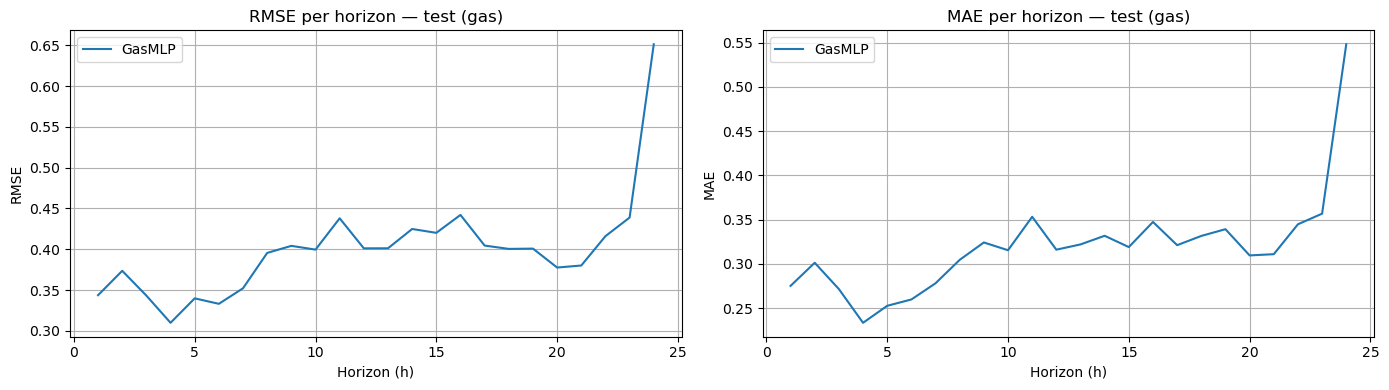

,h,MAE,RMSE,NMAE
0,1,0.275212,0.343821,0.297041
1,2,0.301291,0.373681,0.335492
2,3,0.271574,0.343291,0.291066
3,4,0.233461,0.310012,0.236509
4,5,0.252669,0.339942,0.236469


In [40]:
def per_horizon_metrics(y_true, y_pred):
    y_true_3d = ensure_3d_output(y_true, N_WELLS, HOR)
    y_pred_3d = ensure_3d_output(y_pred, N_WELLS, HOR)
    rows = []
    for h in range(HOR):
        m = mae_rmse_nmae(y_true_3d[:, :, h], y_pred_3d[:, :, h])
        rows.append({"h": h + 1, **m})
    return pd.DataFrame(rows)

test_horizon_df = per_horizon_metrics(test_out["trues_real"], test_out["preds_real"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(test_horizon_df["h"], test_horizon_df["RMSE"], label="GasMLP")
ax1.set(xlabel="Horizon (h)", ylabel="RMSE", title="RMSE per horizon — test (gas)")
ax1.legend(); ax1.grid(True)

ax2.plot(test_horizon_df["h"], test_horizon_df["MAE"], label="GasMLP")
ax2.set(xlabel="Horizon (h)", ylabel="MAE", title="MAE per horizon — test (gas)")
ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()
display(test_horizon_df.head())


In [41]:
T        = len(ts_g)
true_cont = np.full((T, N_WELLS), np.nan)
pred_cont = np.full((T, N_WELLS), np.nan)

preds_3d = ensure_3d_output(test_out["preds_real"], N_WELLS, HOR)
metas    = test_out["metas"]
assert len(metas) == len(preds_3d)

for k, ts0 in enumerate(metas):
    ts0 = int(ts0)
    for j in range(N_WELLS):
        true_cont[ts0 : ts0 + HOR, j] = g_full[ts0 : ts0 + HOR, j]
        pred_cont[ts0 : ts0 + HOR, j] = preds_3d[k, j, :]

n_valid = int(np.sum(np.any(~np.isnan(true_cont), axis=1)))
print(f"Continuous reconstruction: {n_valid} valid hours out of {T}")


Continuous reconstruction: 1464 valid hours out of 8784


72h zoom from 2024-11-01 00:00:00 to 2024-11-03 23:00:00


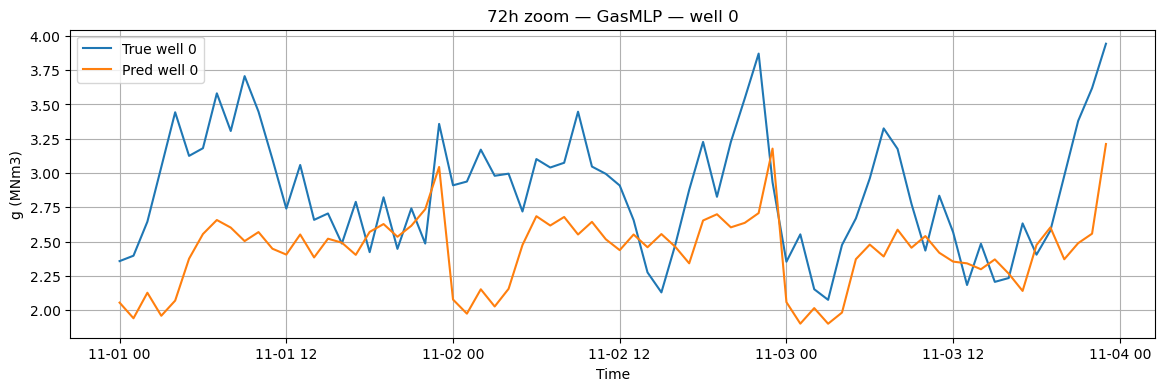

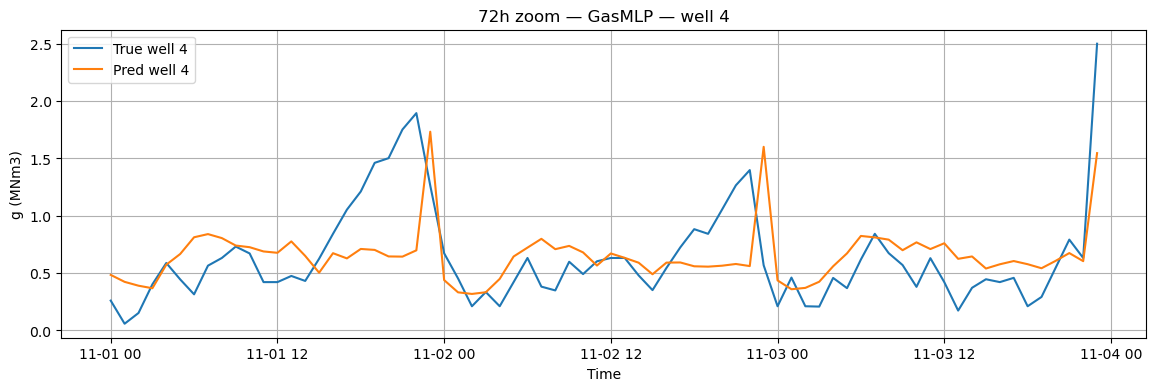

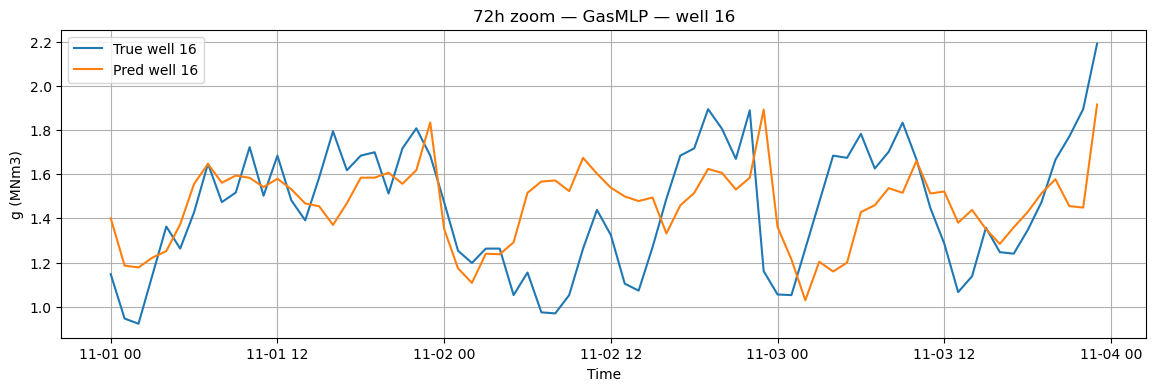

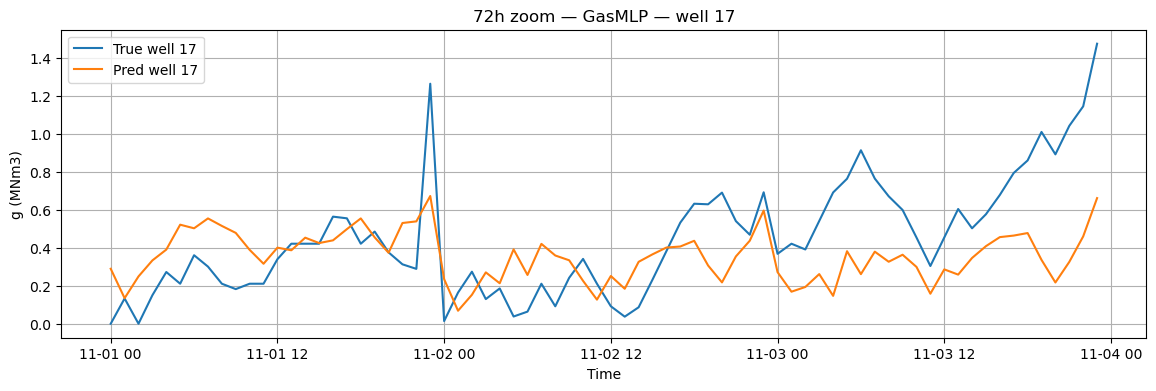

In [42]:
N_ZOOM = 72
valid_hours_mask = np.any(~np.isnan(true_cont), axis=1)
valid_idx        = np.where(valid_hours_mask)[0]
start_plot       = valid_idx[0]
end_plot         = min(start_plot + N_ZOOM, T)

print("72h zoom from", ts_g[start_plot], "to", ts_g[end_plot - 1])

for j in range(min(N_WELLS, 4)):
    w_idx = CONFIG["WELL_IDX"][j]
    plt.figure(figsize=(14, 4))
    plt.plot(ts_g[start_plot:end_plot], true_cont[start_plot:end_plot, j],
             label=f"True well {w_idx}")
    plt.plot(ts_g[start_plot:end_plot], pred_cont[start_plot:end_plot, j],
             label=f"Pred well {w_idx}")
    plt.title(f"72h zoom — GasMLP — well {w_idx}")
    plt.xlabel("Time"); plt.ylabel("g (MNm3)"); plt.grid(True); plt.legend()
    plt.show()


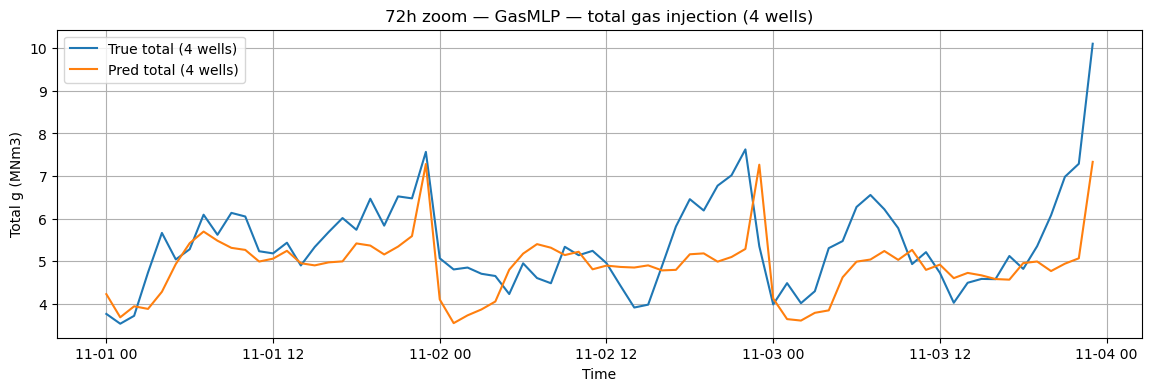

In [43]:
true_total_72h = np.nansum(true_cont[start_plot:end_plot, :], axis=1)
pred_total_72h = np.nansum(pred_cont[start_plot:end_plot, :], axis=1)

plt.figure(figsize=(14, 4))
plt.plot(ts_g[start_plot:end_plot], true_total_72h, label="True total (4 wells)")
plt.plot(ts_g[start_plot:end_plot], pred_total_72h, label="Pred total (4 wells)")
plt.title("72h zoom — GasMLP — total gas injection (4 wells)")
plt.xlabel("Time"); plt.ylabel("Total g (MNm3)"); plt.grid(True); plt.legend()
plt.show()


In [44]:
def aggregated_total_metrics(true_arr, pred_arr, n_wells, horizon):
    true_3d    = ensure_3d_output(true_arr, n_wells, horizon)
    pred_3d    = ensure_3d_output(pred_arr, n_wells, horizon)
    true_total = true_3d.sum(axis=1)
    pred_total = pred_3d.sum(axis=1)
    err_total  = pred_total - true_total
    mae_total  = np.mean(np.abs(err_total))
    rmse_total = np.sqrt(np.mean(err_total ** 2))
    mean_abs   = np.mean(np.abs(true_total))
    return {
        "MAE_total_agg" : mae_total,
        "RMSE_total_agg": rmse_total,
        "STD_error_agg" : np.std(err_total),
        "mean_abs_true" : mean_abs,
        "NMAE_total_agg": mae_total / (mean_abs + 1e-12),
    }, true_total, pred_total, err_total

mlp_metrics, mlp_true_tot, mlp_pred_tot, _ = aggregated_total_metrics(
    test_out["trues_real"], test_out["preds_real"], N_WELLS, HOR)

display(pd.DataFrame([{"model": "GasMLP", **mlp_metrics}]))


,model,MAE_total_agg,RMSE_total_agg,STD_error_agg,mean_abs_true,NMAE_total_agg
0,GasMLP,0.630822,0.813646,0.80341,5.216006,0.12094


=== GasMLP | Global metrics on validation (total injection 4 wells) ===
MAE            : 0.583984
RMSE           : 0.768140
MAE/mean       : 0.123289
Roughness err  : 0.207725
Roughness true : 0.642459
Roughness pred : 0.434734


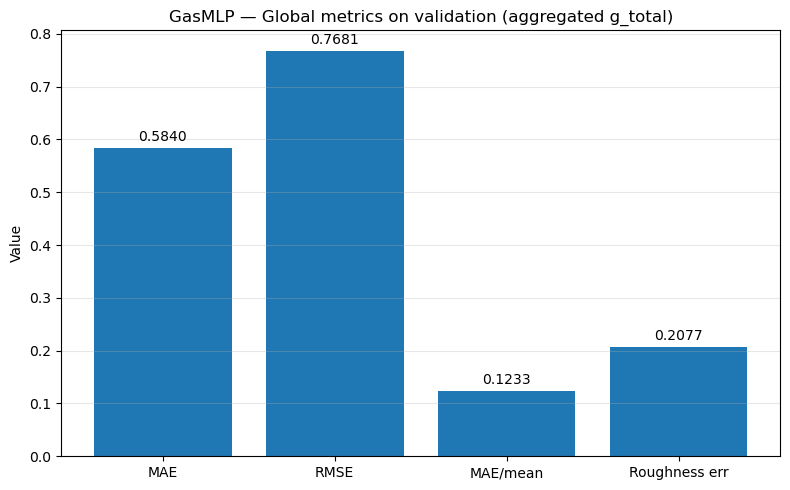

Figure saved to: C:\Users\yoans\TFE - GAZ\figures\global_metrics_val_gas_mlp.png


In [45]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true).reshape(-1) - np.asarray(y_pred).reshape(-1)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true).reshape(-1) - np.asarray(y_pred).reshape(-1))))

def roughness(x):
    x = np.asarray(x).reshape(-1)
    return float(np.mean(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

pred_real_3d = ensure_3d_output(val_out["preds_real"], N_WELLS, HOR)
true_real_3d = ensure_3d_output(val_out["trues_real"], N_WELLS, HOR)
p_pred_total = pred_real_3d.sum(axis=1).reshape(-1)
p_true_total = true_real_3d.sum(axis=1).reshape(-1)

metric_mae  = mae(p_true_total, p_pred_total)
metric_rmse = rmse(p_true_total, p_pred_total)
rough_true  = roughness(p_true_total)
rough_pred  = roughness(p_pred_total)

metrics_val = {
    "MAE"          : metric_mae,
    "RMSE"         : metric_rmse,
    "MAE/mean"     : metric_mae / (np.mean(np.abs(p_true_total)) + 1e-12),
    "Roughness err": abs(rough_pred - rough_true),
}

print("=== GasMLP | Global metrics on validation (total injection 4 wells) ===")
for k, v in metrics_val.items():
    print(f"{k:<15}: {v:.6f}")
print(f"{'Roughness true':<15}: {rough_true:.6f}")
print(f"{'Roughness pred':<15}: {rough_pred:.6f}")

names, values = list(metrics_val.keys()), list(metrics_val.values())
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, values)
ax.set_title("GasMLP — Global metrics on validation (aggregated g_total)")
ax.set_ylabel("Value"); ax.grid(True, axis="y", alpha=0.3)
ymax = max(values) if values else 1.0
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01 * ymax,
            f"{v:.4f}", ha="center", va="bottom", fontsize=10)
fig.tight_layout()

save_dir  = CONFIG["BASE_DIR"] / "figures"
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "global_metrics_val_gas_mlp.png"
fig.savefig(save_path, dpi=140, bbox_inches="tight")
plt.show()
print("Figure saved to:", save_path.resolve())


In [46]:
N_WELLS_ = N_WELLS
HOR_     = HOR
test_out_ = test_out

def _to_3d_pred(arr, n_wells, hor):
    return ensure_3d_output(arr, n_wells, hor)

def mae_rmse(y_true, y_pred):
    y_true_f = np.asarray(y_true).reshape(-1)
    y_pred_f = np.asarray(y_pred).reshape(-1)
    return {"MAE" : float(np.mean(np.abs(y_true_f - y_pred_f))),
            "RMSE": float(np.sqrt(np.mean((y_true_f - y_pred_f)**2)))}

print("Diagnostic aliases defined.")


Diagnostic aliases defined.


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (14, 5), "axes.titlesize": 17, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 19, "lines.linewidth": 2.0, "axes.grid": True,
    "grid.alpha": 0.35, "axes.spines.top": False, "axes.spines.right": False,
})


,horizon_h,model_MAE,model_RMSE
0,1,0.275212,0.343821
1,2,0.301291,0.373681
2,3,0.271574,0.343291
3,4,0.233461,0.310012
4,5,0.252669,0.339942
5,6,0.259818,0.333253
6,7,0.278117,0.352305
7,8,0.304592,0.395590
8,9,0.324243,0.404241
9,10,0.315465,0.399633


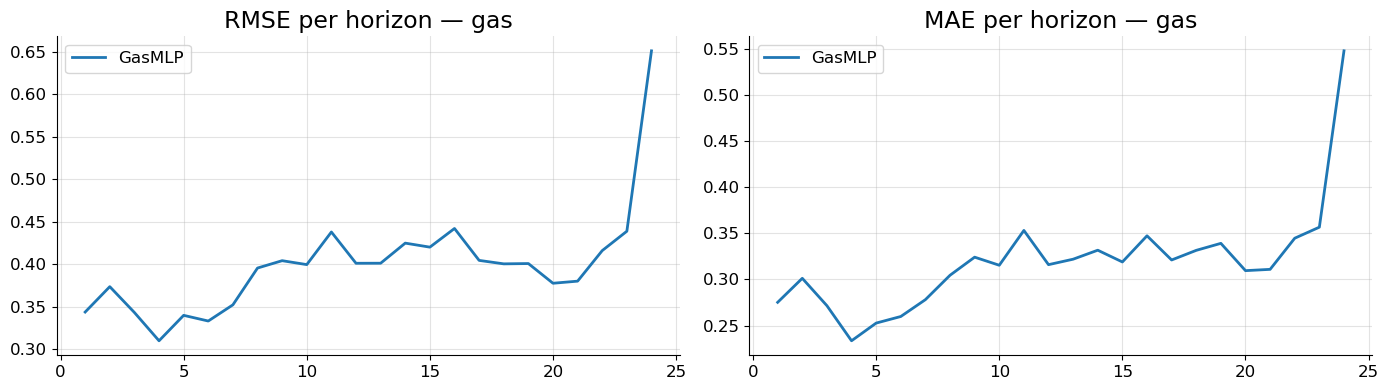

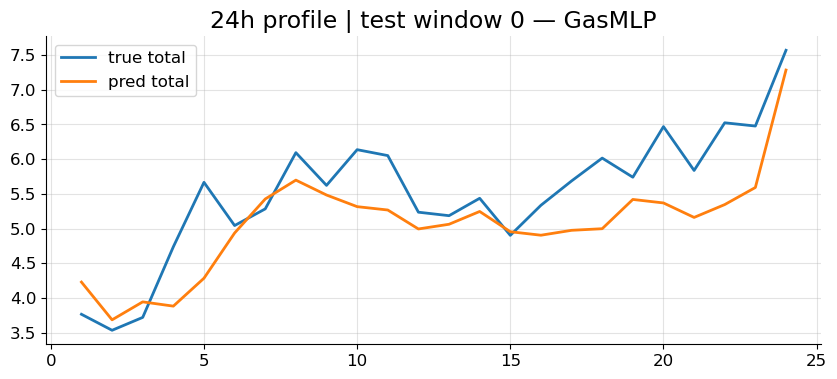

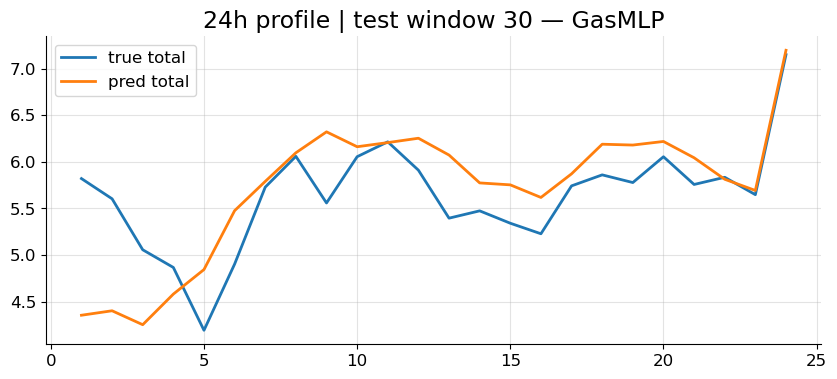

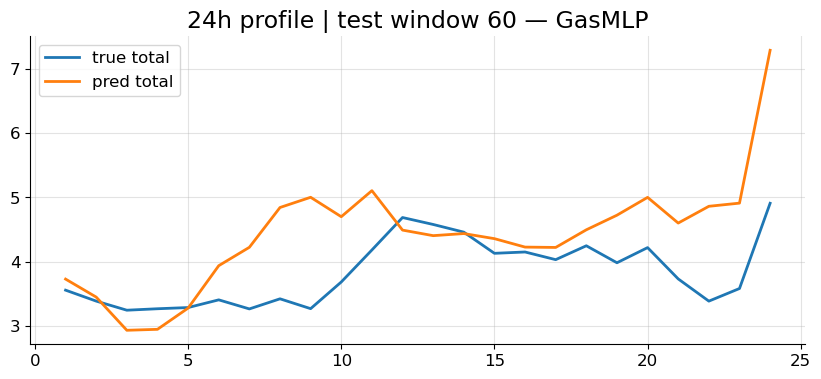

In [49]:
y_true3 = _to_3d_pred(test_out_["trues_real"], N_WELLS_, HOR_)
y_pred3 = _to_3d_pred(test_out_["preds_real"], N_WELLS_, HOR_)

rows = []
for h in range(HOR_):
    m = mae_rmse(y_true3[:, :, h], y_pred3[:, :, h])
    rows.append({"horizon_h": h + 1, "model_MAE": m["MAE"], "model_RMSE": m["RMSE"]})
horizon_df = pd.DataFrame(rows)
display(horizon_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(horizon_df["horizon_h"], horizon_df["model_RMSE"], label="GasMLP")
axes[0].set_title("RMSE per horizon — gas"); axes[0].grid(True); axes[0].legend()

axes[1].plot(horizon_df["horizon_h"], horizon_df["model_MAE"], label="GasMLP")
axes[1].set_title("MAE per horizon — gas"); axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()

sel = np.linspace(0, len(y_true3)-1, min(CONFIG["NUM_PLOT_SAMPLES"], len(y_true3))).astype(int)
for k in sel:
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, HOR_+1), np.sum(y_true3[k], axis=0), label="true total")
    plt.plot(np.arange(1, HOR_+1), np.sum(y_pred3[k], axis=0), label="pred total")
    plt.title(f"24h profile | test window {k} — GasMLP"); plt.grid(True); plt.legend(); plt.show()


,well_node_idx,MAE,RMSE,mean_abs_target,NMAE,std_true,std_pred,std_ratio_pred_true
0,0,0.430485,0.535377,2.569704,0.167523,0.512241,0.281864,0.550257
1,4,0.326624,0.410321,0.921857,0.354311,0.460088,0.263694,0.573138
3,17,0.286798,0.343009,0.224024,1.280215,0.250203,0.208769,0.834398
2,16,0.234199,0.287053,1.500422,0.156089,0.367491,0.209967,0.571352


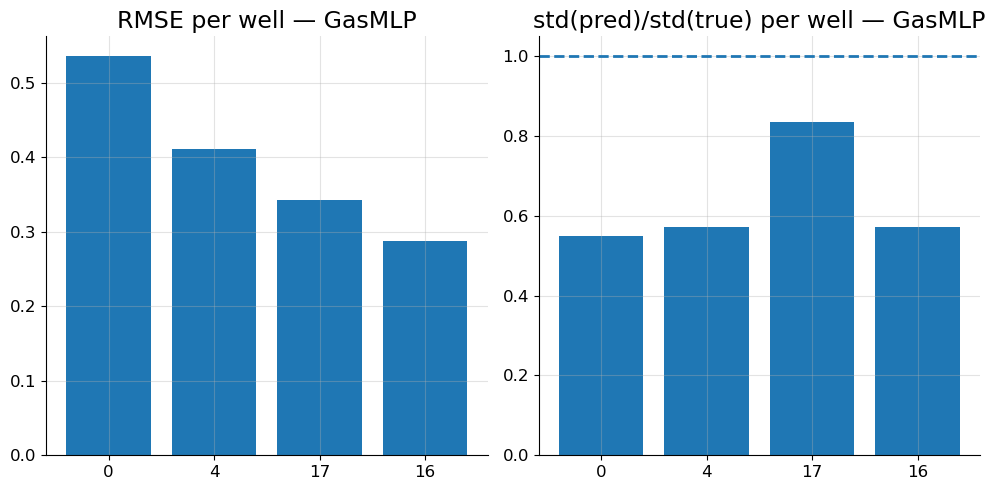

In [50]:
y_true3 = _to_3d_pred(test_out["trues_real"], N_WELLS_, HOR_)
y_pred3 = _to_3d_pred(test_out["preds_real"], N_WELLS_, HOR_)

rows = []
for j, w_idx in enumerate(CONFIG["WELL_IDX"]):
    yt = y_true3[:, j, :]
    yp = y_pred3[:, j, :]
    m  = mae_rmse(yt, yp)
    rows.append({
        "well_node_idx"      : w_idx,
        "MAE"                : m["MAE"],
        "RMSE"               : m["RMSE"],
        "mean_abs_target"    : float(np.mean(np.abs(yt))),
        "NMAE"               : float(m["MAE"] / (np.mean(np.abs(yt)) + 1e-12)),
        "std_true"           : float(np.std(yt)),
        "std_pred"           : float(np.std(yp)),
        "std_ratio_pred_true": float(np.std(yp) / (np.std(yt) + 1e-12)),
    })
well_df_metrics = pd.DataFrame(rows).sort_values("RMSE", ascending=False)
display(well_df_metrics)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(well_df_metrics["well_node_idx"].astype(str), well_df_metrics["RMSE"])
axes[0].set_title("RMSE per well — GasMLP"); axes[0].grid(True, axis="y")

axes[1].bar(well_df_metrics["well_node_idx"].astype(str), well_df_metrics["std_ratio_pred_true"])
axes[1].axhline(1.0, linestyle="--")
axes[1].set_title("std(pred)/std(true) per well — GasMLP"); axes[1].grid(True, axis="y")
plt.tight_layout(); plt.show()


In [52]:
def aggregate_totals_per_hour(arr, n_wells, horizon):
    return ensure_3d_output(arr, n_wells, horizon).sum(axis=1)

mlp_test_pred_tot = aggregate_totals_per_hour(test_out["preds_real"], N_WELLS, HOR)
mlp_test_true_tot = aggregate_totals_per_hour(test_out["trues_real"], N_WELLS, HOR)

m = mae_rmse_nmae(mlp_test_true_tot, mlp_test_pred_tot)
m["model"] = "GasMLP_aggregated_total"

agg_total_df = pd.DataFrame([m])[["model", "MAE", "RMSE", "NMAE"]]
print("=== TEST — Aggregated totals (gas injection) ===")
display(agg_total_df)


=== TEST — Aggregated totals (gas injection) ===


,model,MAE,RMSE,NMAE
0,GasMLP_aggregated_total,0.630822,0.813646,0.12094


In [53]:
def roughness(x):
    x = np.asarray(x).reshape(-1)
    return float(np.mean(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

rough_true = roughness(mlp_test_true_tot)
rough_pred = roughness(mlp_test_pred_tot)

roughness_df = pd.DataFrame([{
    "model"          : "GasMLP",
    "rough_true"     : rough_true,
    "rough_pred"     : rough_pred,
    "rough_error"    : roughness(mlp_test_pred_tot - mlp_test_true_tot),
    "pred_minus_true": rough_pred - rough_true,
    "pred_over_true" : rough_pred / max(rough_true, 1e-12),
}])
print("=== Roughness on aggregated totals — gas injection (TEST) ===")
display(roughness_df)
print(f"  rough_true={rough_true:.4f}  rough_pred={rough_pred:.4f}  pred/true={rough_pred/max(rough_true,1e-12):.3f}")


=== Roughness on aggregated totals — gas injection (TEST) ===


,model,rough_true,rough_pred,rough_error,pred_minus_true,pred_over_true
0,GasMLP,0.599118,0.418415,0.497135,-0.180703,0.698385


  rough_true=0.5991  rough_pred=0.4184  pred/true=0.698
